Diffusion model for regression

Epoch 0, Loss: 0.9739
Epoch 500, Loss: 0.9237
Epoch 1000, Loss: 0.7006
Epoch 1500, Loss: 0.7555
Epoch 2000, Loss: 0.6877
Epoch 2500, Loss: 0.7034
Epoch 3000, Loss: 0.6610
Epoch 3500, Loss: 0.6190
Epoch 4000, Loss: 0.6757
Epoch 4500, Loss: 0.6580


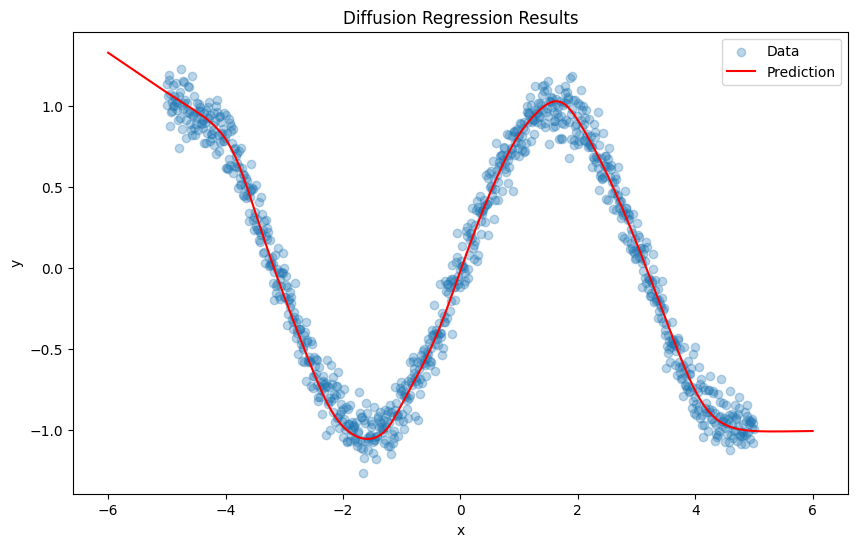

R-squared: 0.9814


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class DiffusionRegression:
    def __init__(self, input_dim, hidden_dim=64):
        self.model = self.create_model(input_dim, hidden_dim)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
        self.scaler_x = StandardScaler()
        self.scaler_y = StandardScaler()

    def create_model(self, input_dim, hidden_dim):
        return tf.keras.Sequential([
            tf.keras.layers.Dense(hidden_dim, activation='swish', input_shape=(input_dim,)),
            tf.keras.layers.Dense(hidden_dim, activation='swish'),
            tf.keras.layers.Dense(hidden_dim, activation='swish'),
            tf.keras.layers.Dense(1)
        ])

    def diffusion_schedule(self, t):
        return 1e-4 + t * 0.02

    @tf.function
    def train_step(self, x, y):
        t = tf.random.uniform((x.shape[0], 1), 0, 1)
        noise = tf.random.normal(y.shape)
        alpha = 1. - self.diffusion_schedule(t)
        noisy_y = tf.sqrt(alpha) * y + tf.sqrt(1 - alpha) * noise
        
        with tf.GradientTape() as tape:
            pred_noise = self.model(tf.concat([x, noisy_y, t], axis=1))
            loss = tf.reduce_mean(tf.square(noise - pred_noise))
        
        gradients = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))
        return loss

    def sample(self, x, steps=100):
        y = tf.random.normal((x.shape[0], 1))
        for i in range(steps-1, -1, -1):
            t = tf.ones((x.shape[0], 1)) * (i / steps)
            alpha = 1. - self.diffusion_schedule(t)
            pred_noise = self.model(tf.concat([x, y, t], axis=1))
            y = (y - tf.sqrt(1 - alpha) * pred_noise) / tf.sqrt(alpha)
        return y

    def train(self, x, y, epochs=5000, batch_size=128):
        x_scaled = self.scaler_x.fit_transform(x)
        y_scaled = self.scaler_y.fit_transform(y)
        
        dataset = tf.data.Dataset.from_tensor_slices((x_scaled, y_scaled)).shuffle(10000).batch(batch_size)

        for epoch in range(epochs):
            losses = []
            for batch_x, batch_y in dataset:
                loss = self.train_step(batch_x, batch_y)
                losses.append(loss)
            
            if epoch % 500 == 0:
                print(f"Epoch {epoch}, Loss: {tf.reduce_mean(losses):.4f}")

    def predict(self, x):
        x_scaled = self.scaler_x.transform(x)
        y_scaled = self.sample(x_scaled)
        return self.scaler_y.inverse_transform(y_scaled)

# Generate example data
np.random.seed(0)
x = np.linspace(-5, 5, 1000).reshape(-1, 1).astype(np.float32)
y = np.sin(x) + 0.1 * np.random.randn(*x.shape).astype(np.float32)

# Create and train the model
model = DiffusionRegression(input_dim=3)
model.train(x, y)

# Generate predictions
x_test = np.linspace(-6, 6, 200).reshape(-1, 1).astype(np.float32)
y_pred = model.predict(x_test)

# Plot results
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.3, label='Data')
plt.plot(x_test, y_pred, 'r', label='Prediction')
plt.legend()
plt.title('Diffusion Regression Results')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Calculate and print R-squared
from sklearn.metrics import r2_score
r2 = r2_score(y, model.predict(x))
print(f"R-squared: {r2:.4f}")